# Experiment 1

Implement a program to acquire and display an image. Demonstrate the process of image sensing and acquisition, and explain the components involved in an image processing system.

### Theory
### Image Sensing and Acquisition
Image acquisition is the first and fundamental step in digital image processing. It involves capturing a real-world scene using a sensing device and converting it into a digital image suitable for computer processing.

The process consists of:
1. Illumination of the scene  
2. Sensing of reflected or transmitted energy  
3. Conversion of energy into electrical signals  
4. Digitization of signals into pixel values  

### Image Acquisition Process

1. Illumination Source  
Provides energy (visible light, infrared, X-ray, etc.) to illuminate the object.

2. Object/Scene  
Reflects or transmits the incident energy.

3. Image Sensor  
Captures the reflected energy using devices such as:  
CCD (Charge Coupled Device)  
CMOS (Complementary Metal Oxide Semiconductor)

4. Analog Signal Generation  
The sensor converts energy into analog electrical signals.

5. Analog-to-Digital Converter (ADC)  
Converts analog signals into digital pixel values.

6. Digital Image Formation  
The output is a matrix of intensity values representing the image.

### Algorithm

1. Import required libraries.  
2. Read the input image using image acquisition function.  
3. Display the acquired image.  
4. Wait for a key press and close display window.

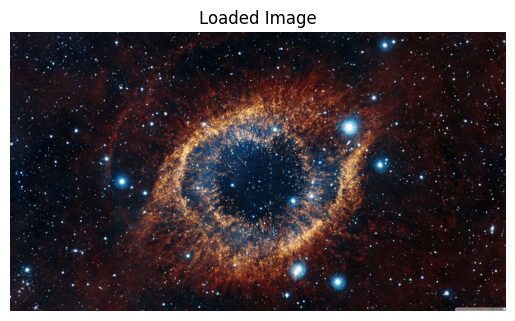

In [1]:
import cv2
import matplotlib.pyplot as plt

# Step 1: Acquire the image from file
image = cv2.imread('image.jpg')

# Step 2: Check if image is successfully loaded
if image is None:
    print("Error: Image not found")
else:
    # Step 3: Convert BGR → RGB (VERY important)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Step 4: Display the loaded image
    plt.imshow(image_rgb)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()

# Experiment 2

Develop a program to perform sampling and quantization on a given image. Visualize the effects of different sampling rates and quantization levels on image quality.

### Theory
### Sampling
Sampling is the process of reducing the spatial resolution of an image by selecting a subset of pixels from the original image.

- High sampling rate → more pixels → better spatial detail  
- Low sampling rate → fewer pixels → loss of fine details (aliasing)  

Sampling affects the spatial resolution of the image.

### Quantization
Quantization is the process of reducing the number of intensity levels used to represent pixel values.

- High quantization levels → smooth intensity transitions  
- Low quantization levels → visible intensity jumps (false contouring)  

Quantization affects the gray-level resolution of the image.

### Algorithm

1. Read the input image.  
2. Convert the image to grayscale.  
3. Perform sampling by down sampling the image at different rates.  
4. Perform quantization using different gray-level values.  
5. Display original and processed images for comparison.

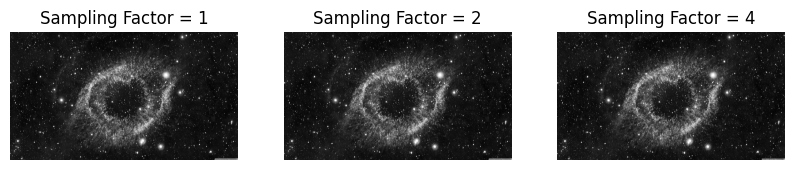

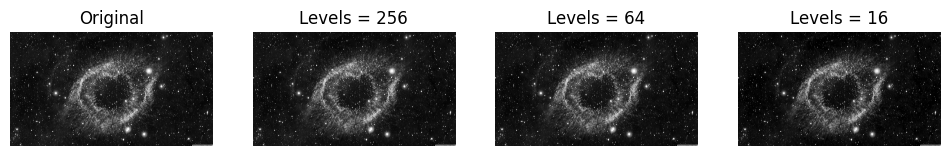

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not found")

# Function for sampling
def sampling(img, factor):
    return img[::factor, ::factor]

# Function for quantization
def quantization(img, levels):
    img_norm = img / 255.0
    img_quant = np.floor(img_norm * levels) / levels
    return (img_quant * 255).astype(np.uint8)

# Sampling factors and quantization levels
sampling_factors = [1, 2, 4]
quant_levels = [256, 64, 16]

# Display sampling results
plt.figure(figsize=(10, 4))
for i, f in enumerate(sampling_factors):
    sampled_img = sampling(image, f)
    sampled_img = cv2.resize(sampled_img, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
    plt.subplot(1, 3, i+1)
    plt.imshow(sampled_img, cmap='gray')
    plt.title(f'Sampling Factor = {f}')
    plt.axis('off')
plt.show()

# Display quantization results with original image
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, q in enumerate(quant_levels):
    quant_img = quantization(image, q)
    plt.subplot(1, 4, i+2)
    plt.imshow(quant_img, cmap='gray')
    plt.title(f'Levels = {q}')
    plt.axis('off')

plt.show()

# Experiment 3

Implement image enhancement techniques in the spatial domain, including contrast stretching and histogram equalization. Compare the results before and after enhancement.

### Theory

Image enhancement in the spatial domain operates directly on pixel intensities to improve the visual appearance of an image. Contrast stretching increases the dynamic range of intensity values, while histogram equalization redistributes intensity levels to enhance global contrast.

### Algorithm

1. Read the input image and convert it to grayscale.  
2. Apply contrast stretching using minimum and maximum intensity values.  
3. Perform histogram equalization on the image.  
4. Display original and enhanced images.  

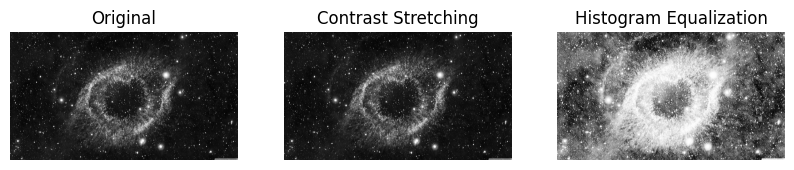

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Contrast Stretching
min_val, max_val = np.min(img), np.max(img)
cs_img = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# Histogram Equalization
he_img = cv2.equalizeHist(img)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(cs_img, cmap='gray'); plt.title('Contrast Stretching'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(he_img, cmap='gray'); plt.title('Histogram Equalization'); plt.axis('off')
plt.show()

# Experiment 4

Apply frequency domain filtering to an image. Implement both low pass and high pass filters, and demonstrate their effects.

### Theory

Frequency domain filtering modifies image characteristics by manipulating its Fourier transform. Low pass filters reduce noise and blur the image, whereas high pass filters enhance edges.

### Algorithm

1. Convert image to frequency domain using FFT.  
2. Apply low pass and high pass masks.  
3. Convert back to spatial domain using inverse FFT.  

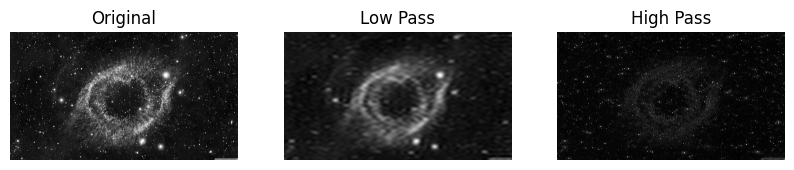

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

mask_lp = np.zeros((rows, cols), np.uint8)
mask_lp[crow-30:crow+30, ccol-30:ccol+30] = 1
mask_hp = 1 - mask_lp

lp = np.fft.ifft2(np.fft.ifftshift(fshift * mask_lp))
hp = np.fft.ifft2(np.fft.ifftshift(fshift * mask_hp))

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.abs(lp), cmap='gray'); plt.title('Low Pass'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(np.abs(hp), cmap='gray'); plt.title('High Pass'); plt.axis('off')
plt.show()


# Experiment 5

Implement a noise model and apply spatial filtering techniques for image restoration.

### Theory

Noise degrades image quality during acquisition or transmission. Gaussian noise and salt-and-pepper noise are common models. Spatial filters such as mean and median filters are used for restoration.

### Algorithm

1. Add Gaussian and salt-and-pepper noise to the image.  
2. Apply mean and median filtering.  
3. Compare noisy and restored images.  

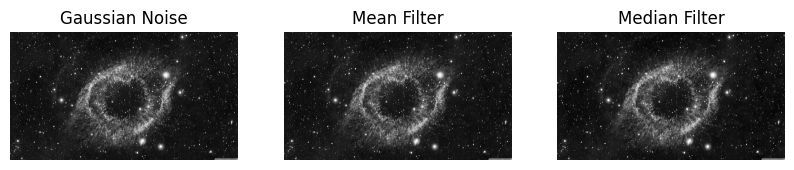

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Gaussian Noise
gauss = img + np.random.normal(0, 20, img.shape)
gauss = np.clip(gauss, 0, 255).astype(np.uint8)

# Salt & Pepper Noise
sp = img.copy()
prob = 0.02
rand = np.random.rand(*img.shape)
sp[rand < prob] = 0
sp[rand > 1-prob] = 255

mean_filt = cv2.blur(gauss, (3,3))
median_filt = cv2.medianBlur(sp, 3)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(gauss, cmap='gray'); plt.title('Gaussian Noise'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mean_filt, cmap='gray'); plt.title('Mean Filter'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(median_filt, cmap='gray'); plt.title('Median Filter'); plt.axis('off')
plt.show()

# Experiment 6
### Theory

Inverse filtering attempts to reverse degradation, while Wiener filtering minimizes mean square error considering noise.

### Algorithm

1. Add periodic noise.  
2. Apply inverse filter.  
3. Apply Wiener filter.  

c:\Users\91962\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_signaltools.py:1673: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
c:\Users\91962\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_signaltools.py:1673: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


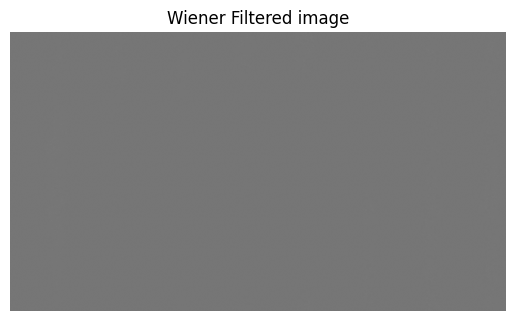

In [4]:
import sys
from scipy.signal import wiener
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)
noise = 20 * np.sin(np.linspace(0,50,img.shape[1]))
noise = noise.reshape(1,-1)
noisy = img + noise
noisy = np.clip(noisy,0,255).astype(np.uint8)

wiener_img = wiener(noisy)

plt.imshow(wiener_img, cmap='gray')
plt.title('Wiener Filtered image')
plt.axis('off')
plt.show()

# Experiment 7

Implement geometric transformations such as rotation, scaling, and translation.

### Theory

Geometric transformations modify image geometry without changing intensity values.

### Algorithm

1. Read image.  
2. Apply translation, scaling, and rotation.  
3. Display results.  

In [ ]:
import cv2
import numpy as np

img = cv2.imread('image.jpg')
rows, cols = img.shape[:2]

M_trans = np.float32([[1,0,50],[0,1,50]])
translated = cv2.warpAffine(img, M_trans, (cols, rows))

scaled = cv2.resize(img, None, fx=0.5, fy=0.5)

M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
rotated = cv2.warpAffine(img, M_rot, (cols, rows))

cv2.imshow('Translated', translated)
cv2.imshow('Scaled', scaled)
cv2.imshow('Rotated', rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Experiment 8

Perform color image processing by converting an image from RGB to another color model (HSV, YCbCr). Implement and visualize color-based image segmentation techniques.

### Theory

Color image processing involves transforming an image from one color space to another for better analysis. The HSV color model separates intensity from color information, making segmentation easier. Color-based segmentation isolates regions based on specific color ranges.

### Algorithm

1. Read the color image.  
2. Convert RGB image to HSV color space.  
3. Define color range for segmentation.  
4. Create mask and extract segmented region.  
5. Display original and segmented images.  

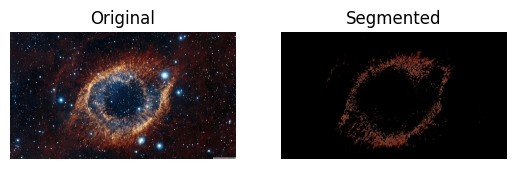

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower = np.array([0, 120, 70])
upper = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower, upper)
segmented = cv2.bitwise_and(img, img, mask=mask)

plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)); plt.title('Segmented'); plt.axis('off')
plt.show()


# Experiment 9

Implement Huffman Coding and Run Length Coding for image compression. Compare compression ratios.

### Theory

Image compression reduces storage requirements. Run Length Encoding (RLE) compresses consecutive repeated pixels, while Huffman coding assigns variable-length codes based on frequency of occurrence.

### Algorithm

1. Read grayscale image.  
2. Flatten image array.  
3. Apply RLE compression.  
4. Apply Huffman coding.  
5. Compare compression ratios.  

In [1]:
import cv2
import numpy as np
from collections import Counter
import heapq

img = cv2.imread('image.jpg', 0)
flat = img.flatten()

# Run Length Encoding
rle = []
prev = flat[0]
count = 1
for pixel in flat[1:]:
    if pixel == prev:
        count += 1
    else:
        rle.append((prev, count))
        prev = pixel
        count = 1
rle.append((prev, count))

print("Original size:", len(flat))
print("RLE size:", len(rle))

Original size: 8294400
RLE size: 7666576


# Experiment 10

Perform image segmentation using edge detection techniques.

### Theory

Edge detection identifies object boundaries by detecting intensity discontinuities. Canny edge detector is widely used for accurate edge localization.

### Algorithm

1. Read grayscale image.  
2. Apply Canny edge detection.  
3. Perform edge linking.  
4. Display segmented boundaries.  

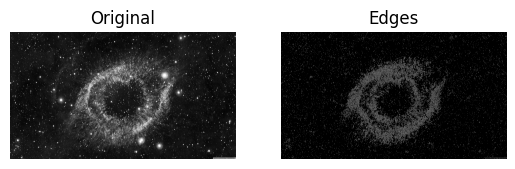

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)
edges = cv2.Canny(img, 100, 200)

plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(edges, cmap='gray'); plt.title('Edges'); plt.axis('off')
plt.show()

# Experiment 11

Apply morphological operations such as dilation and erosion on a binary image.

### Theory

Morphological operations process binary images based on structuring elements. Erosion shrinks objects, while dilation expands them.

### Algorithm

1. Convert image to binary.  
2. Define structuring element.  
3. Apply erosion and dilation.  
4. Display results.  

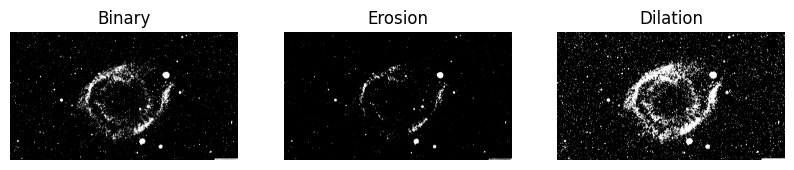

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

if img is None:
    raise ValueError("Image not found")

_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)
erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(binary, cmap='gray')
plt.title('Binary')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')
plt.axis('off')

plt.show()

# Experiment 12

Implement threshold-based and region-based segmentation techniques.

### Theory

Threshold segmentation separates objects based on intensity values, while region-based segmentation groups neighboring pixels with similar properties.

### Algorithm

1. Apply global thresholding.  
2. Apply region growing.  
3. Compare results.  

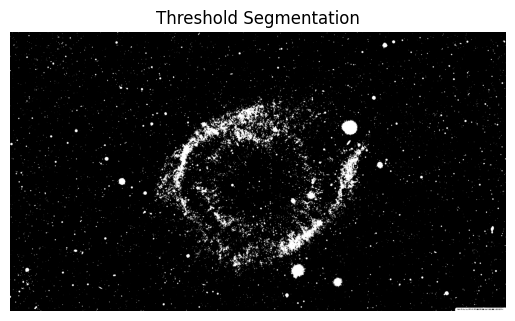

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

if img is None:
    raise ValueError("Image not found")

_, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title('Threshold Segmentation')
plt.axis('off')
plt.show()

# Experiment 13

Implement boundary and regional descriptors using chain codes.

### Theory

Boundary descriptors represent object shape using chain codes, which encode direction changes along boundaries.

### Algorithm

1. Extract object boundary.  
2. Traverse boundary pixels.  
3. Encode directions as chain codes.  

In [7]:
import cv2

img = cv2.imread('image.jpg', 0)
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

print("Number of boundary points:", len(contours[0]))

Number of boundary points: 2


# Experiment 14

Develop a basic Convolutional Neural Network (CNN) for image classification.

### Theory

CNNs automatically learn hierarchical features from images using convolution, pooling, and fully connected layers.

### Algorithm

1. Load dataset.  
2. Define CNN model.  
3. Train model.  
4. Evaluate accuracy.  

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
MaxPooling2D((2,2)),
Flatten(),
Dense(128, activation='relu'),
Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


ModuleNotFoundError: No module named 'tensorflow'

# Experiment 15

Implement Huffman coding for image compression.

### Theory

Huffman coding reduces redundancy by assigning shorter codes to frequent symbols.

### Algorithm

1. Read image.  
2. Convert to grayscale.  
3. Count pixel frequencies.  

In [12]:
import cv2
from collections import Counter

img = cv2.imread('image.jpg', 0)
freq = Counter(img.flatten())
print("Pixel Frequencies:", freq)

Pixel Frequencies: Counter({np.uint8(17): 290547, np.uint8(18): 290383, np.uint8(16): 287138, np.uint8(19): 284769, np.uint8(15): 277182, np.uint8(20): 274242, np.uint8(14): 265621, np.uint8(21): 263467, np.uint8(22): 249206, np.uint8(13): 248049, np.uint8(23): 234139, np.uint8(12): 226754, np.uint8(24): 218177, np.uint8(25): 202928, np.uint8(11): 202775, np.uint8(26): 186883, np.uint8(10): 176876, np.uint8(27): 171814, np.uint8(28): 157898, np.uint8(9): 149730, np.uint8(29): 144209, np.uint8(30): 132172, np.uint8(8): 123528, np.uint8(31): 120346, np.uint8(32): 110166, np.uint8(33): 100725, np.uint8(7): 97998, np.uint8(34): 92408, np.uint8(35): 84713, np.uint8(36): 78212, np.uint8(6): 75083, np.uint8(37): 72235, np.uint8(38): 67221, np.uint8(39): 62616, np.uint8(40): 58674, np.uint8(41): 55042, np.uint8(5): 54998, np.uint8(42): 51891, np.uint8(43): 49181, np.uint8(44): 47047, np.uint8(45): 44911, np.uint8(46): 42605, np.uint8(47): 40668, np.uint8(48): 39231, np.uint8(4): 38096, np.uint

# Experiment 16

Shannon–Fano Coding and Arithmetic Coding

### Theory

Shannon–Fano and Arithmetic coding are entropy-based compression methods.

### Algorithm

1. Read image.  
2. Compute symbol probabilities.  

In [14]:
import cv2
import numpy as np

img = cv2.imread('image.jpg', 0)
values, counts = np.unique(img, return_counts=True)
prob = counts / counts.sum()

print("Symbol Probabilities:", prob)

Symbol Probabilities: [0.00150837 0.00121588 0.00200364 0.00313573 0.00459298 0.00663074
 0.00905225 0.01181496 0.01489294 0.01805194 0.02132475 0.02444722
 0.0273382  0.0299056  0.03202414 0.03341797 0.0346183  0.0350293
 0.03500952 0.03433268 0.03306351 0.03176444 0.03004509 0.02822856
 0.02630413 0.02446566 0.02253123 0.02071446 0.0190367  0.01738631
 0.01593509 0.01450931 0.01328197 0.01214374 0.01114101 0.01021328
 0.00942949 0.00870889 0.00810438 0.00754919 0.00707393 0.00663604
 0.00625615 0.00592942 0.00567214 0.00541462 0.0051366  0.00490307
 0.00472982 0.00457019 0.00436873 0.00424142 0.00412736 0.00401271
 0.00390758 0.00377459 0.00371275 0.00357952 0.00347608 0.00340447
 0.00331706 0.00321856 0.00314538 0.00308931 0.00300492 0.00293174
 0.00284553 0.00283601 0.00274076 0.00268953 0.00262454 0.00256571
 0.00248734 0.00246962 0.00238788 0.00234773 0.00227672 0.00224597
 0.00220788 0.00214108 0.00208418 0.00204487 0.00201148 0.00197784
 0.00194179 0.00188537 0.00181653 0.00178